In [1]:
#Imports
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

In [2]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Basic settings
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 0.0005

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
#set paths

# Root dataset folder
root_path = "/content/drive/MyDrive/CCMT Dataset"

# Crop-specific folders
cashew_path = os.path.join(root_path, "Cashew")
maize_path = os.path.join(root_path, "Maize")

# Check folder structure
print("Root folders:", os.listdir(root_path))
print("Cashew classes:", os.listdir(cashew_path))
print("Maize classes:", os.listdir(maize_path))

# Store paths in a dictionary for easy access
crop_paths = {
    "Cashew": cashew_path,
    "Maize": maize_path
}

# Check folder structure
print("Root folders:", os.listdir(root_path))
print("Cashew classes:", os.listdir(cashew_path))
print("Maize classes:", os.listdir(maize_path))

Root folders: ['Maize', 'Cashew']
Cashew classes: ['anthracnose', 'red rust', 'healthy', 'leaf miner', 'gumosis']
Maize classes: ['leaf beetle', 'fall armyworm', 'leaf blight', 'grasshoper', 'streak virus', 'leaf spot', 'healthy']
Root folders: ['Maize', 'Cashew']
Cashew classes: ['anthracnose', 'red rust', 'healthy', 'leaf miner', 'gumosis']
Maize classes: ['leaf beetle', 'fall armyworm', 'leaf blight', 'grasshoper', 'streak virus', 'leaf spot', 'healthy']


In [5]:
#Helper to skip broken images
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except:
        return False

In [6]:
#remove broken images from both crops
bad_files = []

for crop_name, crop_path in crop_paths.items():
    for root, _, files in os.walk(crop_path):
        for file in files:
            path = os.path.join(root, file)
            try:
                with Image.open(path) as img:
                    img.load()
            except Exception:
                bad_files.append(path)

print("Bad files found:", len(bad_files))

for f in bad_files:
    try:
        os.remove(f)
    except Exception as e:
        print("Could not delete:", f, e)

Bad files found: 0



Cashew Class Distribution
Class distribution:
anthracnose: 1729
gumosis: 392
healthy: 1368
leaf miner: 1378
red rust: 1682


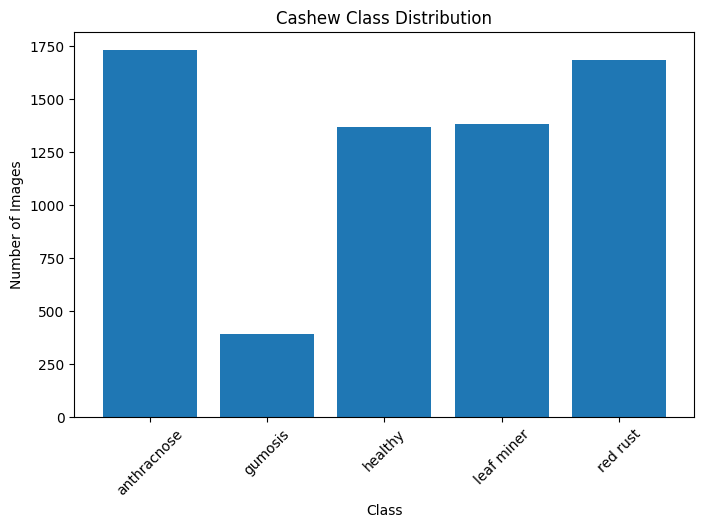


Maize Class Distribution
Class distribution:
fall armyworm: 285
grasshoper: 673
healthy: 204
leaf beetle: 933
leaf blight: 990
leaf spot: 1239
streak virus: 965


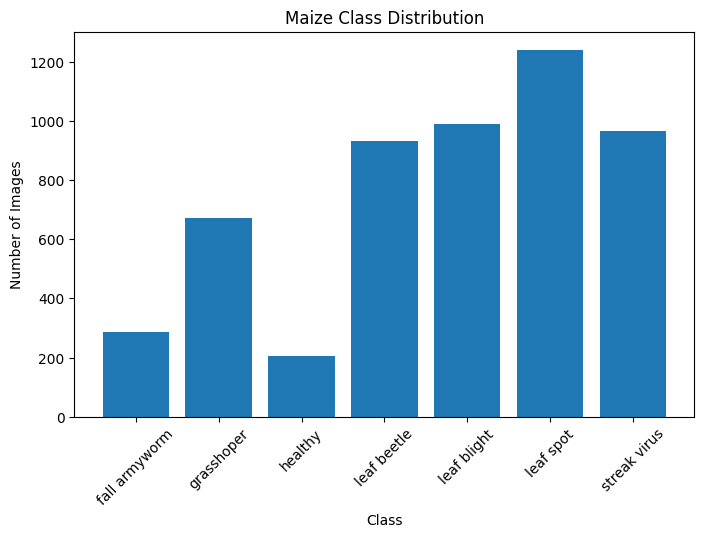

In [7]:
#Show class distribution for both crops
for crop_name, crop_path in crop_paths.items():
    print("\n" + "=" * 50)
    print(f"{crop_name} Class Distribution")
    print("=" * 50)

    dataset = datasets.ImageFolder(crop_path, is_valid_file=is_valid_image)
    class_names = dataset.classes
    num_classes = len(class_names)

    label_counts = Counter(dataset.targets)

    print("Class distribution:")
    for class_idx, count in label_counts.items():
        print(f"{class_names[class_idx]}: {count}")

    plt.figure(figsize=(8, 5))
    plt.bar(
        [class_names[i] for i in range(num_classes)],
        [label_counts[i] for i in range(num_classes)]
    )
    plt.title(f"{crop_name} Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    plt.show()

In [8]:
#Dataset wrapper for different transforms
class TransformedSubset(Subset):
    def __init__(self, dataset, indices, transform=None):
        super().__init__(dataset, indices)
        self.transform = transform

    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]

        if self.transform:
            x = self.transform(x)

        return x, y

In [9]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()

        # Convolution blocks
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 -> 28

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 28 -> 14
        )

        # Global average pooling makes the classifier much smaller
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [10]:
#model selection
def get_model(model_name, num_classes):
    if model_name == "custom_cnn":
        model = CustomCNN(num_classes)

    elif model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

    elif model_name == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)

    else:
        raise ValueError("Invalid model_name")

    return model.to(device)

In [11]:
#Training function
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [12]:
#Evaluation function
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            total_loss += loss.item() * images.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    return (
        total_loss / total,
        correct / total,
        np.array(y_true),
        np.array(y_pred),
        np.array(y_prob)
    )

In [13]:
# Show a few images from a DataLoader
def show_images(loader, class_names, n=6):
    images, labels = next(iter(loader))
    plt.figure(figsize=(12, 6))

    for i in range(min(n, len(images))):
        img = images[i].cpu().numpy().transpose(1, 2, 0)

        # Undo normalization for display
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [14]:
def run_crop_experiment(crop_name, model_name, show_samples=False):
    # Print which crop and model are being trained
    print(f"\n===== {crop_name} | {model_name} =====")

    # Load the dataset for the selected crop
    # is_valid_file skips corrupted/broken images
    dataset = datasets.ImageFolder(
        crop_paths[crop_name],
        is_valid_file=is_valid_image
    )

    # Store class names and number of classes
    class_names = dataset.classes
    num_classes = len(class_names)

    # Get labels and sample indices
    targets = np.array(dataset.targets)
    indices = np.arange(len(dataset))

    # ---------------------------
    # 1. Split the dataset
    # ---------------------------
    # First split:
    # 70% for training
    # 30% temporary split (validation + test)
    train_idx, temp_idx = train_test_split(
        indices,
        test_size=0.3,
        stratify=targets,   # keeps class distribution balanced
        random_state=42
    )

    # Second split:
    # split the temporary set equally into validation and test
    temp_targets = targets[temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.5,
        stratify=temp_targets,
        random_state=42
    )

    # ---------------------------
    # 2. Compute class weights
    # ---------------------------
    # This helps if some classes have fewer samples than others
    # Smaller classes get larger weights in the loss function
    train_labels = targets[train_idx]
    class_counts = np.bincount(train_labels, minlength=num_classes)

    class_weights = len(train_labels) / (num_classes * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    print("Class counts:", class_counts)

    # ---------------------------
    # 3. Define image transforms
    # ---------------------------
    # Training transform includes augmentation
    # This helps the model generalize better
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],   # ImageNet mean
            std=[0.229, 0.224, 0.225]     # ImageNet std
        )
    ])

    # Validation/test transform does NOT include augmentation
    # We want these sets to remain unchanged for fair evaluation
    eval_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # ---------------------------
    # 4. Create datasets
    # ---------------------------
    # We create separate ImageFolder datasets so train can use
    # train_transform and val/test can use eval_transform
    train_dataset = datasets.ImageFolder(
        crop_paths[crop_name],
        transform=train_transform,
        is_valid_file=is_valid_image
    )

    val_dataset = datasets.ImageFolder(
        crop_paths[crop_name],
        transform=eval_transform,
        is_valid_file=is_valid_image
    )

    test_dataset = datasets.ImageFolder(
        crop_paths[crop_name],
        transform=eval_transform,
        is_valid_file=is_valid_image
    )

    # Use Subset to select only the indices for each split
    train_data = Subset(train_dataset, train_idx)
    val_data = Subset(val_dataset, val_idx)
    test_data = Subset(test_dataset, test_idx)

    # Quick check: confirm that transformed images are tensors
    img, label = train_data[0]
    print("Sample type:", type(img))
    print("Sample shape:", img.shape)

    # ---------------------------
    # 5. Create DataLoaders
    # ---------------------------
    # DataLoader loads data in mini-batches during training
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Show a few training images to verify preprocessing and labels
    if show_samples:
        show_images(train_loader, class_names)

    # ---------------------------
    # 6. Create model, loss, optimizer
    # ---------------------------
    # get_model() returns the chosen architecture
    model = get_model(model_name, num_classes)

    # CrossEntropyLoss is standard for multi-class classification
    # class_weights helps with imbalance
    # Adam optimizer updates weights during training

    # Use slightly different training settings for custom CNN vs pretrained models
    if model_name == "custom_cnn":
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Track the best validation accuracy
    best_val_acc = 0.0
    best_model_path = f"best_{crop_name}_{model_name}.pth"

    # Early stopping settings:
    # if validation accuracy does not improve for 'patience' epochs, stop
    patience = 4
    epochs_no_improve = 0

    # Lists for plotting training curves later
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    # ---------------------------
    # 7. Training loop
    # ---------------------------
    for epoch in range(NUM_EPOCHS):
        # Train for one epoch
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)

        # Evaluate on validation set
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion)

        # Save metrics for plotting
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # Print epoch results
        print(
            f"Epoch {epoch+1}: "
            f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
            f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}"
        )

        # Save model if validation accuracy improves
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        # Stop early if model stops improving
        if epochs_no_improve >= patience:
            print("Early stopping triggered.")
            break

    # ---------------------------
    # 8. Final test evaluation
    # ---------------------------
    # Load the best saved model before testing
    model.load_state_dict(torch.load(best_model_path, map_location=device))

    # Evaluate on the test set
    _, test_acc, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion)

    print(f"\nTest Accuracy ({crop_name} - {model_name}): {test_acc:.4f}")

    # Return everything needed for plots and reports
    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "class_names": class_names,
        "test_acc": test_acc,
        "crop_name": crop_name,
        "model_name": model_name,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs
    }

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

def plot_results(result):
    # ---------------------------
    # 1. Plot training curves
    # ---------------------------
    # These show how loss and accuracy changed over epochs
    plt.figure(figsize=(12, 5))

    # Loss curve
    plt.subplot(1, 2, 1)
    plt.plot(result["train_losses"], label="Train Loss")
    plt.plot(result["val_losses"], label="Val Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy curve
    plt.subplot(1, 2, 2)
    plt.plot(result["train_accs"], label="Train Acc")
    plt.plot(result["val_accs"], label="Val Acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # ---------------------------
    # 2. Confusion matrix
    # ---------------------------
    # This shows which classes are being confused with each other
    y_true = result["y_true"]
    y_pred = result["y_pred"]
    class_names = result["class_names"]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.colorbar()
    plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=45)
    plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    # ---------------------------
    # 3. Print classification metrics
    # ---------------------------
    print("Crop:", result["crop_name"])
    print("Model:", result["model_name"])
    print("Accuracy:", round(result["test_acc"], 4))

    # classification_report gives precision, recall, and F1-score per class
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

In [21]:
# Print a few test predictions and compare them with the true labels
def print_actual_vs_predicted(result, num_samples=20):
    # Extract saved true labels, predicted labels, and class names
    y_true = result["y_true"]
    y_pred = result["y_pred"]
    class_names = result["class_names"]

    # Print how many samples will be shown
    print(f"Showing first {min(num_samples, len(y_true))} predictions:\n")

    # Loop through the selected number of samples
    for i in range(min(num_samples, len(y_true))):
        # Convert numeric class indices to readable class names
        actual_label = class_names[y_true[i]]
        predicted_label = class_names[y_pred[i]]

        # Check whether the prediction was correct
        status = "Correct" if y_true[i] == y_pred[i] else "Wrong"

        # Print the result for this sample
        print(f"Sample {i+1}: Actual = {actual_label} | Predicted = {predicted_label} | {status}")

In [16]:
def plot_multiclass_roc(result):
    y_true = result["y_true"]
    y_prob = result["y_prob"]
    class_names = result["class_names"]
    crop_name = result["crop_name"]
    model_name = result["model_name"]

    num_classes = len(class_names)

    # Convert true labels to one-vs-rest binary format
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

    plt.figure(figsize=(8, 6))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{class_names[i]} (AUC = {roc_auc:.2f})"
        )

    # Diagonal reference line
    plt.plot([0, 1], [0, 1], "k--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {crop_name} - {model_name}")
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(True)
    plt.show()


===== Maize | custom_cnn =====
Class counts: [200 471 143 653 693 867 675]
Sample type: <class 'torch.Tensor'>
Sample shape: torch.Size([3, 224, 224])


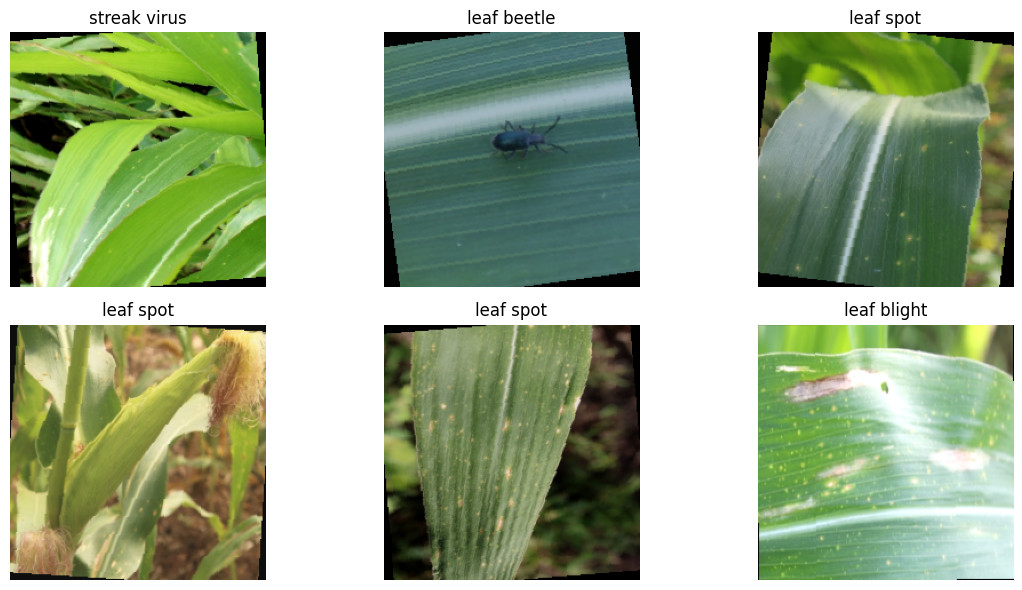

Epoch 1: Train Loss=1.7676, Train Acc=0.3225, Val Loss=1.5541, Val Acc=0.4578
Epoch 2: Train Loss=1.5846, Train Acc=0.4552, Val Loss=1.5325, Val Acc=0.4817
Epoch 3: Train Loss=1.5046, Train Acc=0.5289, Val Loss=1.4412, Val Acc=0.5649
Epoch 4: Train Loss=1.4840, Train Acc=0.5359, Val Loss=1.4573, Val Acc=0.5271
Epoch 5: Train Loss=1.4456, Train Acc=0.5535, Val Loss=1.4177, Val Acc=0.5612
Epoch 6: Train Loss=1.4112, Train Acc=0.5546, Val Loss=1.4204, Val Acc=0.6053
Epoch 7: Train Loss=1.3962, Train Acc=0.5837, Val Loss=1.3498, Val Acc=0.5612
Epoch 8: Train Loss=1.3646, Train Acc=0.5954, Val Loss=1.2858, Val Acc=0.6494
Epoch 9: Train Loss=1.3605, Train Acc=0.6002, Val Loss=1.3779, Val Acc=0.5473
Epoch 10: Train Loss=1.3223, Train Acc=0.6267, Val Loss=1.2436, Val Acc=0.6179
Epoch 11: Train Loss=1.3191, Train Acc=0.6216, Val Loss=1.3330, Val Acc=0.5612
Epoch 12: Train Loss=1.2995, Train Acc=0.6353, Val Loss=1.2314, Val Acc=0.6608
Epoch 13: Train Loss=1.2902, Train Acc=0.6445, Val Loss=1.199

In [19]:
result_cnn_maize = run_crop_experiment("Maize", "custom_cnn", show_samples=True)

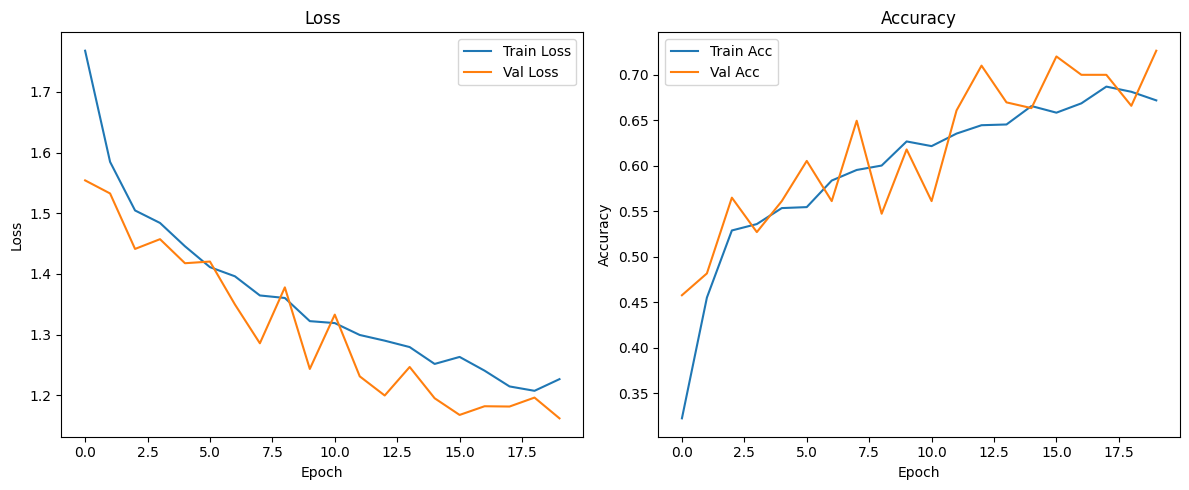

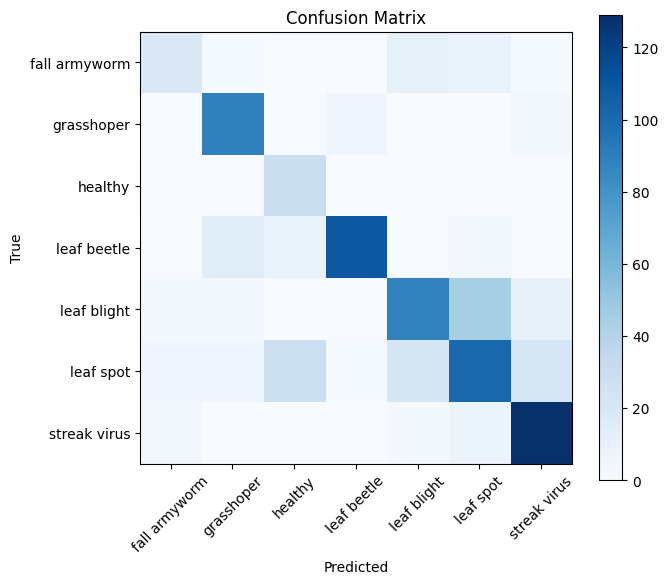

Crop: Maize
Model: custom_cnn
Accuracy: 0.7091
               precision    recall  f1-score   support

fall armyworm       0.55      0.42      0.47        43
   grasshoper       0.77      0.88      0.82       101
      healthy       0.43      0.97      0.59        30
  leaf beetle       0.92      0.78      0.84       140
  leaf blight       0.70      0.59      0.64       149
    leaf spot       0.61      0.54      0.57       186
 streak virus       0.77      0.89      0.82       145

     accuracy                           0.71       794
    macro avg       0.68      0.72      0.68       794
 weighted avg       0.72      0.71      0.71       794



In [20]:
plot_results(result_cnn_maize)

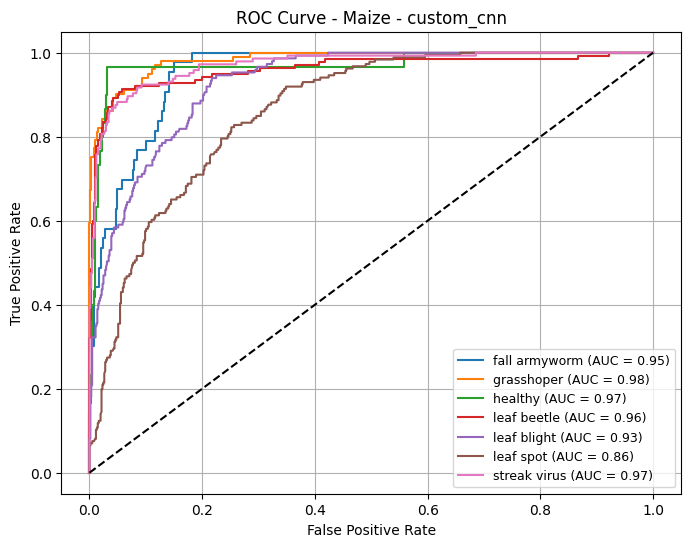

In [22]:
plot_multiclass_roc(result_cnn_maize)

In [27]:
print_actual_vs_predicted(result_cnn_maize, num_samples=20)

Showing first 20 predictions:

Sample 1: Actual = leaf spot | Predicted = leaf blight | Wrong
Sample 2: Actual = leaf spot | Predicted = streak virus | Wrong
Sample 3: Actual = healthy | Predicted = healthy | Correct
Sample 4: Actual = leaf blight | Predicted = leaf spot | Wrong
Sample 5: Actual = fall armyworm | Predicted = fall armyworm | Correct
Sample 6: Actual = streak virus | Predicted = streak virus | Correct
Sample 7: Actual = leaf blight | Predicted = leaf blight | Correct
Sample 8: Actual = leaf blight | Predicted = leaf spot | Wrong
Sample 9: Actual = leaf spot | Predicted = streak virus | Wrong
Sample 10: Actual = leaf spot | Predicted = streak virus | Wrong
Sample 11: Actual = leaf beetle | Predicted = leaf beetle | Correct
Sample 12: Actual = leaf spot | Predicted = leaf spot | Correct
Sample 13: Actual = leaf beetle | Predicted = healthy | Wrong
Sample 14: Actual = leaf spot | Predicted = healthy | Wrong
Sample 15: Actual = leaf spot | Predicted = leaf spot | Correct
Sam


===== Cashew | custom_cnn =====
Class counts: [1210  274  958  965 1177]
Sample type: <class 'torch.Tensor'>
Sample shape: torch.Size([3, 224, 224])


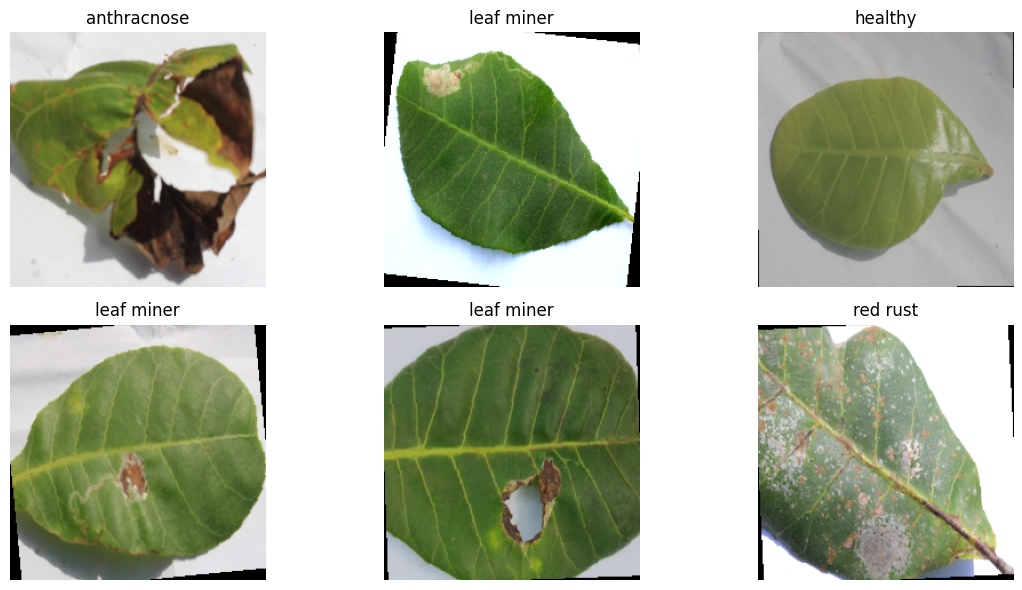

Epoch 1: Train Loss=1.2592, Train Acc=0.5308, Val Loss=1.0409, Val Acc=0.6813
Epoch 2: Train Loss=1.1032, Train Acc=0.6475, Val Loss=1.0244, Val Acc=0.7138
Epoch 3: Train Loss=1.0587, Train Acc=0.6826, Val Loss=0.9283, Val Acc=0.7648
Epoch 4: Train Loss=0.9989, Train Acc=0.7260, Val Loss=0.9139, Val Acc=0.7495
Epoch 5: Train Loss=0.9604, Train Acc=0.7380, Val Loss=0.8955, Val Acc=0.7770
Epoch 6: Train Loss=0.9269, Train Acc=0.7768, Val Loss=0.8190, Val Acc=0.8187
Epoch 7: Train Loss=0.8939, Train Acc=0.7921, Val Loss=0.9178, Val Acc=0.7800
Epoch 8: Train Loss=0.8673, Train Acc=0.8161, Val Loss=0.7412, Val Acc=0.8849
Epoch 9: Train Loss=0.8574, Train Acc=0.8216, Val Loss=0.7808, Val Acc=0.8534
Epoch 10: Train Loss=0.8325, Train Acc=0.8336, Val Loss=0.7445, Val Acc=0.8747
Epoch 11: Train Loss=0.8173, Train Acc=0.8477, Val Loss=0.7514, Val Acc=0.8890
Epoch 12: Train Loss=0.7932, Train Acc=0.8589, Val Loss=0.8800, Val Acc=0.7790
Epoch 13: Train Loss=0.8014, Train Acc=0.8584, Val Loss=0.810

In [28]:
result_cnn_cashew = run_crop_experiment("Cashew", "custom_cnn", show_samples=True)

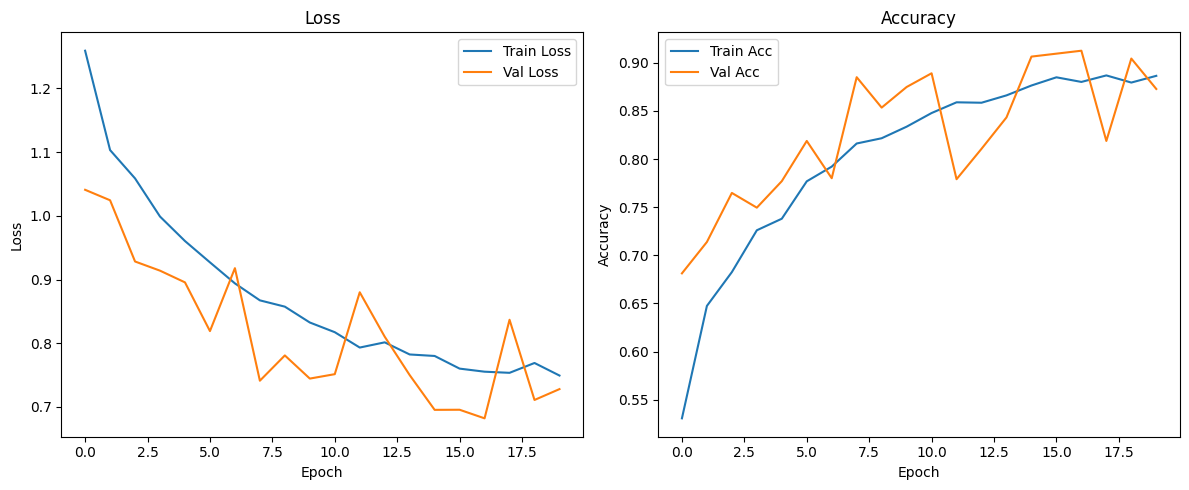

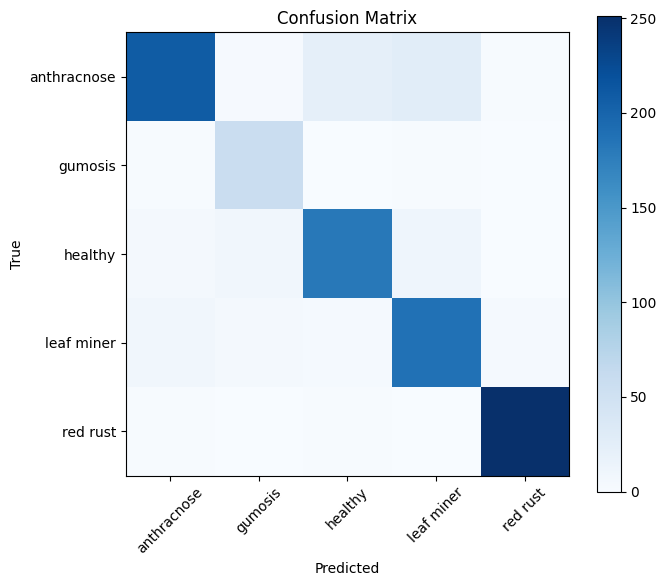

Crop: Cashew
Model: custom_cnn
Accuracy: 0.9003
              precision    recall  f1-score   support

 anthracnose       0.93      0.80      0.86       260
     gumosis       0.80      0.97      0.88        59
     healthy       0.87      0.88      0.88       205
  leaf miner       0.83      0.91      0.87       206
    red rust       0.98      0.99      0.99       253

    accuracy                           0.90       983
   macro avg       0.88      0.91      0.89       983
weighted avg       0.90      0.90      0.90       983



In [29]:
plot_results(result_cnn_cashew)

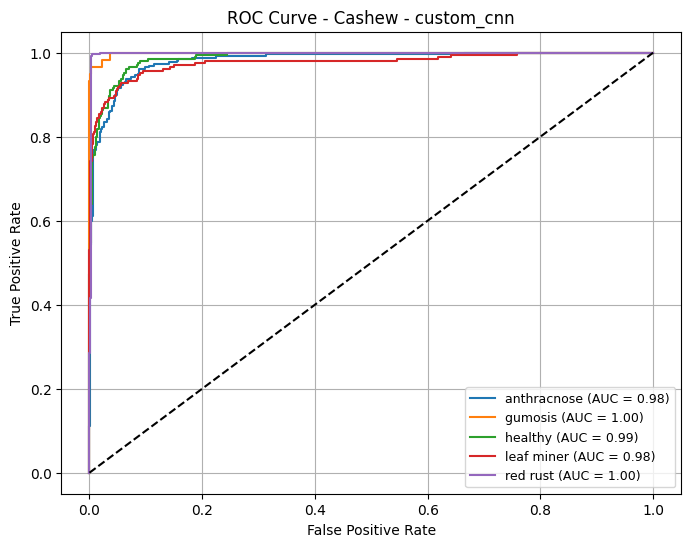

In [30]:
plot_multiclass_roc(result_cnn_cashew)

In [31]:
print_actual_vs_predicted(result_cnn_cashew, num_samples=20)

Showing first 20 predictions:

Sample 1: Actual = red rust | Predicted = red rust | Correct
Sample 2: Actual = anthracnose | Predicted = leaf miner | Wrong
Sample 3: Actual = leaf miner | Predicted = leaf miner | Correct
Sample 4: Actual = anthracnose | Predicted = anthracnose | Correct
Sample 5: Actual = red rust | Predicted = red rust | Correct
Sample 6: Actual = healthy | Predicted = healthy | Correct
Sample 7: Actual = anthracnose | Predicted = anthracnose | Correct
Sample 8: Actual = anthracnose | Predicted = healthy | Wrong
Sample 9: Actual = red rust | Predicted = red rust | Correct
Sample 10: Actual = healthy | Predicted = gumosis | Wrong
Sample 11: Actual = red rust | Predicted = red rust | Correct
Sample 12: Actual = anthracnose | Predicted = anthracnose | Correct
Sample 13: Actual = healthy | Predicted = healthy | Correct
Sample 14: Actual = red rust | Predicted = red rust | Correct
Sample 15: Actual = healthy | Predicted = healthy | Correct
Sample 16: Actual = gumosis | Pre


===== Maize | resnet18 =====
Class counts: [200 471 143 653 693 867 675]
Sample type: <class 'torch.Tensor'>
Sample shape: torch.Size([3, 224, 224])
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


Epoch 1: Train Loss=0.7679, Train Acc=0.6775, Val Loss=0.6498, Val Acc=0.7402
Epoch 2: Train Loss=0.5365, Train Acc=0.7599, Val Loss=0.6681, Val Acc=0.7781
Epoch 3: Train Loss=0.4703, Train Acc=0.7912, Val Loss=0.5587, Val Acc=0.7831
Epoch 4: Train Loss=0.4290, Train Acc=0.8160, Val Loss=0.3830, Val Acc=0.8222
Epoch 5: Train Loss=0.3547, Train Acc=0.8347, Val Loss=0.4916, Val Acc=0.7945
Epoch 6: Train Loss=0.3557, Train Acc=0.8390, Val Loss=0.4111, Val Acc=0.8285
Epoch 7: Train Loss=0.3368, Train Acc=0.8452, Val Loss=0.4364, Val Acc=0.8335
Epoch 8: Train Loss=0.3079, Train Acc=0.8585, Val Loss=0.4138, Val Acc=0.8247
Epoch 9: Train Loss=0.2889, Train Acc=0.8622, Val Loss=0.5463, Val Acc=0.7970
Epoch 10: Train Loss=0.2760, Train Acc=0.8655, Val Loss=0.5519, Val Acc=0.7781
Epoch 11: Train Loss=0.2476, Train Acc=0.8779, Val Loss=0.4470, Val Acc=0.8335
Early stopping triggered.

Test Accuracy (Maize - resnet18): 0.8060


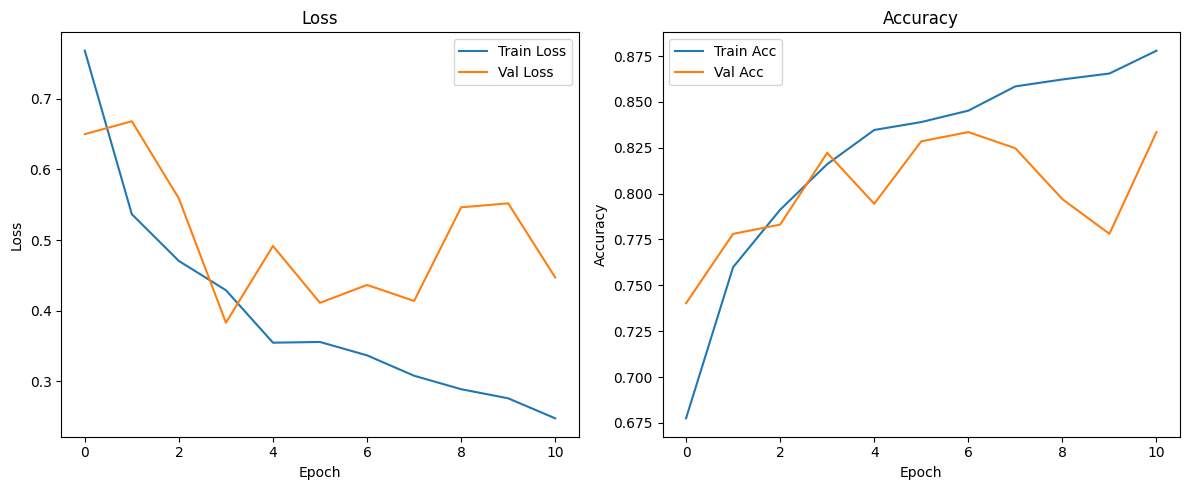

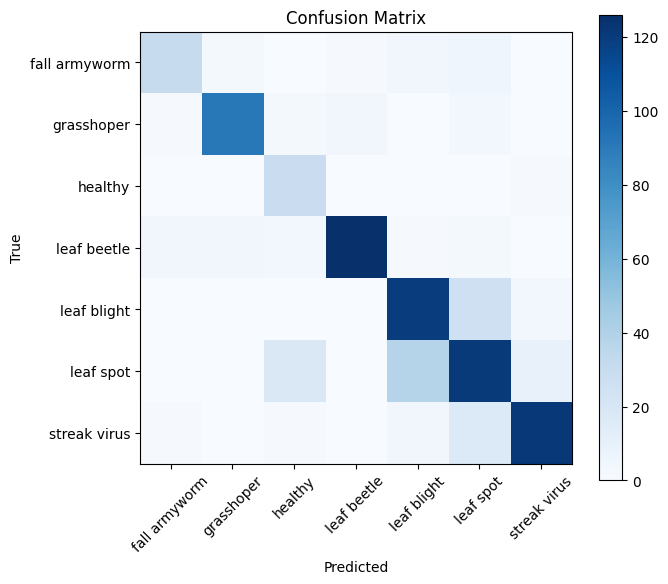

Crop: Maize
Model: resnet18
Accuracy: 0.806
               precision    recall  f1-score   support

fall armyworm       0.84      0.72      0.78        43
   grasshoper       0.94      0.90      0.92       101
      healthy       0.55      0.97      0.70        30
  leaf beetle       0.96      0.90      0.93       140
  leaf blight       0.72      0.81      0.76       149
    leaf spot       0.70      0.65      0.67       186
 streak virus       0.90      0.84      0.87       145

     accuracy                           0.81       794
    macro avg       0.80      0.83      0.80       794
 weighted avg       0.82      0.81      0.81       794



In [ ]:
result_resnet_maize  = run_crop_experiment("Maize", "resnet18")
plot_results(result_resnet_maize)


===== Cashew | resnet18 =====
Class counts: [1210  274  958  965 1177]
Sample type: <class 'torch.Tensor'>
Sample shape: torch.Size([3, 224, 224])
Epoch 1: Train Loss=0.3498, Train Acc=0.8748, Val Loss=0.4425, Val Acc=0.8493
Epoch 2: Train Loss=0.2232, Train Acc=0.9186, Val Loss=0.1777, Val Acc=0.9267
Epoch 3: Train Loss=0.1789, Train Acc=0.9354, Val Loss=0.1679, Val Acc=0.9399
Epoch 4: Train Loss=0.1788, Train Acc=0.9367, Val Loss=0.1582, Val Acc=0.9348
Epoch 5: Train Loss=0.1505, Train Acc=0.9448, Val Loss=0.1990, Val Acc=0.9297
Epoch 6: Train Loss=0.1481, Train Acc=0.9472, Val Loss=0.1192, Val Acc=0.9572
Epoch 7: Train Loss=0.1555, Train Acc=0.9446, Val Loss=0.5259, Val Acc=0.9328
Epoch 8: Train Loss=0.1954, Train Acc=0.9315, Val Loss=0.1809, Val Acc=0.9338
Epoch 9: Train Loss=0.1521, Train Acc=0.9498, Val Loss=0.1362, Val Acc=0.9450
Epoch 10: Train Loss=0.1008, Train Acc=0.9618, Val Loss=0.1548, Val Acc=0.9420
Early stopping triggered.

Test Accuracy (Cashew - resnet18): 0.9563


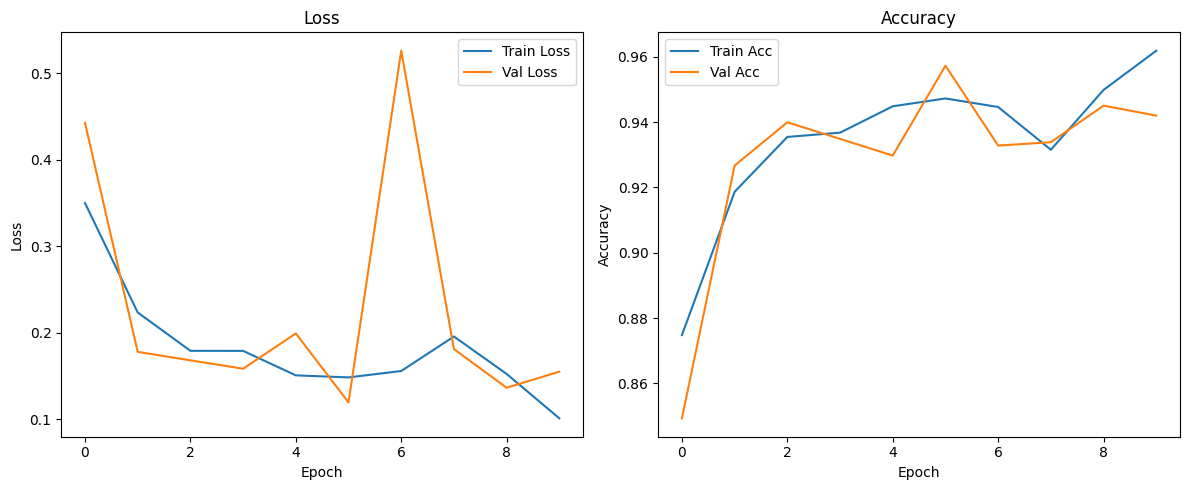

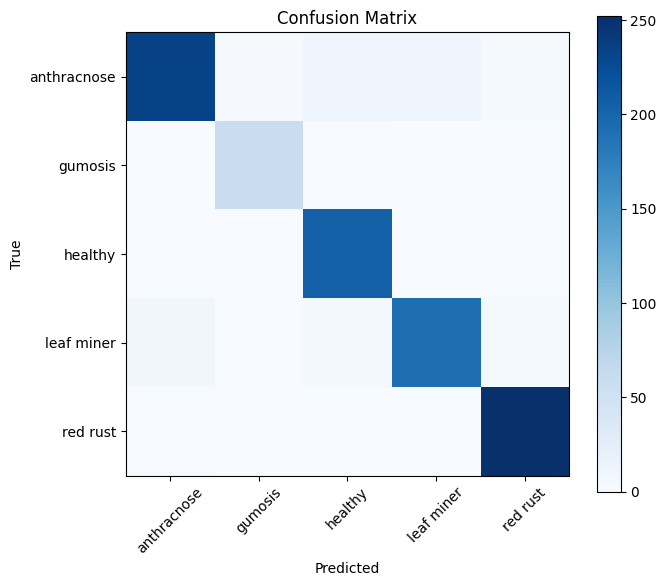

Crop: Cashew
Model: resnet18
Accuracy: 0.9563
              precision    recall  f1-score   support

 anthracnose       0.96      0.90      0.93       260
     gumosis       0.97      0.98      0.97        59
     healthy       0.93      1.00      0.96       205
  leaf miner       0.95      0.93      0.94       206
    red rust       0.98      1.00      0.99       253

    accuracy                           0.96       983
   macro avg       0.96      0.96      0.96       983
weighted avg       0.96      0.96      0.96       983



In [ ]:
result_resnet_cashew = run_crop_experiment("Cashew", "resnet18")
plot_results(result_resnet_cashew)

In [ ]:
result_eff_maize  = run_crop_experiment("Maize", "efficientnet_b0")


===== Maize | efficientnet_b0 =====
Class counts: [200 471 143 653 693 867 675]
Sample type: <class 'torch.Tensor'>
Sample shape: torch.Size([3, 224, 224])
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 119MB/s]


Epoch 1: Train Loss=0.6869, Train Acc=0.7366, Val Loss=0.4405, Val Acc=0.8184
Epoch 2: Train Loss=0.3646, Train Acc=0.8301, Val Loss=0.3603, Val Acc=0.8285
Epoch 3: Train Loss=0.2707, Train Acc=0.8682, Val Loss=0.3699, Val Acc=0.8499
Epoch 4: Train Loss=0.2334, Train Acc=0.8830, Val Loss=0.3719, Val Acc=0.8588
Epoch 5: Train Loss=0.2410, Train Acc=0.8817, Val Loss=0.3555, Val Acc=0.8550
Epoch 6: Train Loss=0.1881, Train Acc=0.9052, Val Loss=0.3533, Val Acc=0.8436
Epoch 7: Train Loss=0.1597, Train Acc=0.9155, Val Loss=0.3657, Val Acc=0.8663
Epoch 8: Train Loss=0.1759, Train Acc=0.9106, Val Loss=0.4772, Val Acc=0.8247
Epoch 9: Train Loss=0.1766, Train Acc=0.9098, Val Loss=0.3725, Val Acc=0.8676
Epoch 10: Train Loss=0.1534, Train Acc=0.9225, Val Loss=0.3594, Val Acc=0.8600
Epoch 11: Train Loss=0.1353, Train Acc=0.9233, Val Loss=0.4105, Val Acc=0.8550
Epoch 12: Train Loss=0.1289, Train Acc=0.9295, Val Loss=0.4278, Val Acc=0.8386
Epoch 13: Train Loss=0.1171, Train Acc=0.9357, Val Loss=0.472

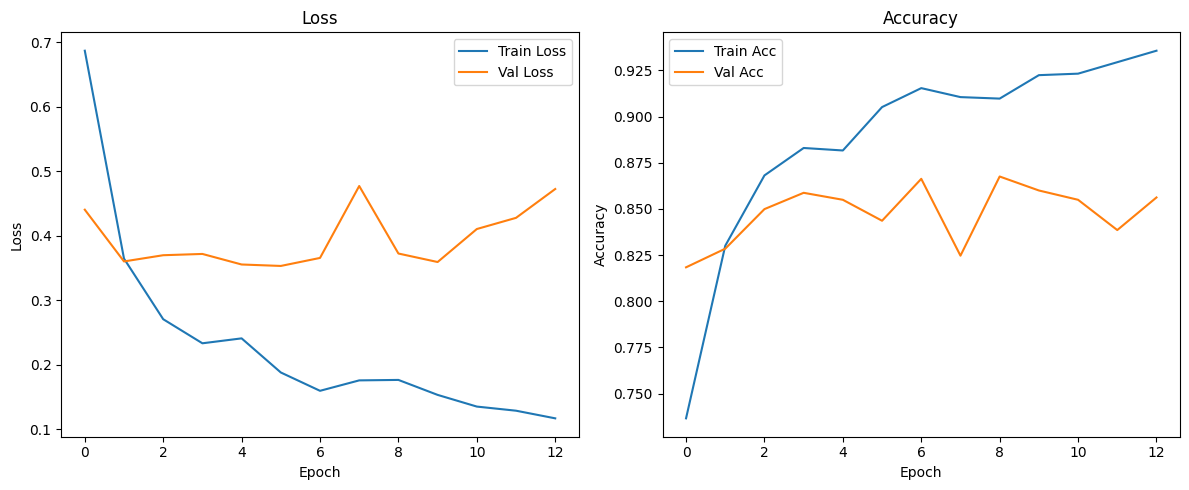

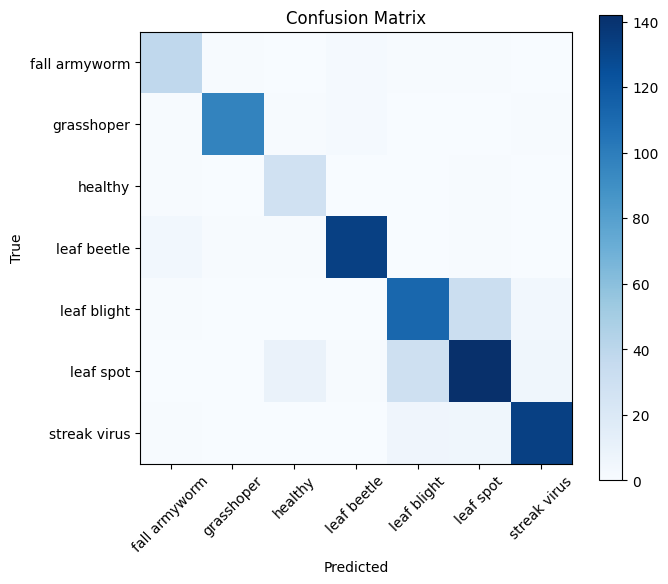

Crop: Maize
Model: efficientnet_b0
Accuracy: 0.8589
               precision    recall  f1-score   support

fall armyworm       0.83      0.88      0.85        43
   grasshoper       0.98      0.95      0.96       101
      healthy       0.72      0.93      0.81        30
  leaf beetle       0.96      0.95      0.96       140
  leaf blight       0.76      0.75      0.75       149
    leaf spot       0.78      0.76      0.77       186
 streak virus       0.93      0.92      0.92       145

     accuracy                           0.86       794
    macro avg       0.85      0.88      0.86       794
 weighted avg       0.86      0.86      0.86       794



In [ ]:
plot_results(result_eff_maize)

In [ ]:
result_eff_cashew = run_crop_experiment("Cashew", "efficientnet_b0")


===== Cashew | efficientnet_b0 =====
Class counts: [1210  274  958  965 1177]
Sample type: <class 'torch.Tensor'>
Sample shape: torch.Size([3, 224, 224])
Epoch 1: Train Loss=0.3301, Train Acc=0.8861, Val Loss=0.1931, Val Acc=0.9226
Epoch 2: Train Loss=0.1659, Train Acc=0.9400, Val Loss=0.1252, Val Acc=0.9582
Epoch 3: Train Loss=0.1178, Train Acc=0.9579, Val Loss=0.0893, Val Acc=0.9705
Epoch 4: Train Loss=0.0889, Train Acc=0.9636, Val Loss=0.0827, Val Acc=0.9735
Epoch 5: Train Loss=0.0698, Train Acc=0.9732, Val Loss=0.0809, Val Acc=0.9725
Epoch 6: Train Loss=0.0680, Train Acc=0.9758, Val Loss=0.1121, Val Acc=0.9603
Epoch 7: Train Loss=0.0686, Train Acc=0.9769, Val Loss=0.1196, Val Acc=0.9633
Epoch 8: Train Loss=0.0660, Train Acc=0.9740, Val Loss=0.1133, Val Acc=0.9572
Early stopping triggered.

Test Accuracy (Cashew - efficientnet_b0): 0.9573


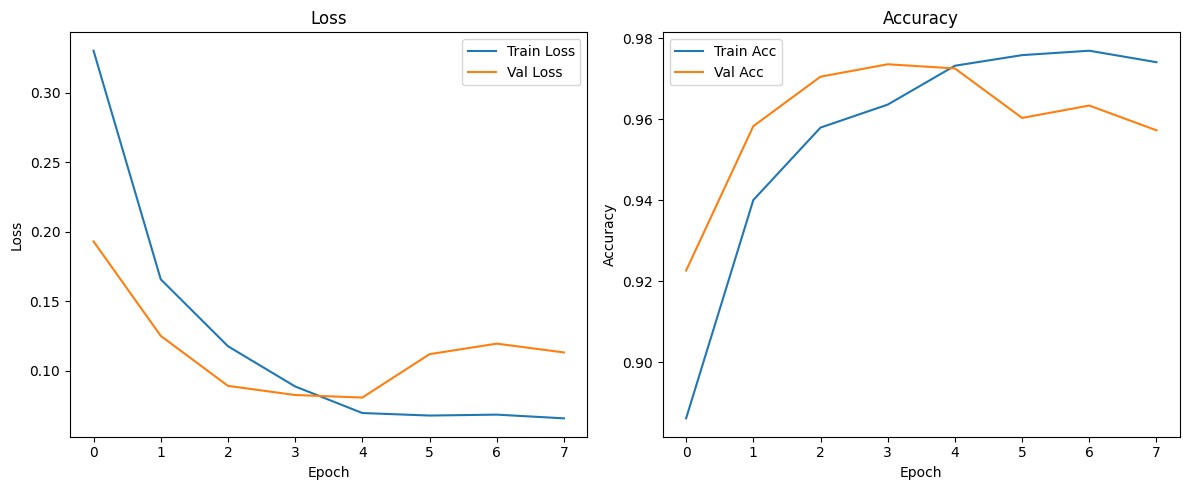

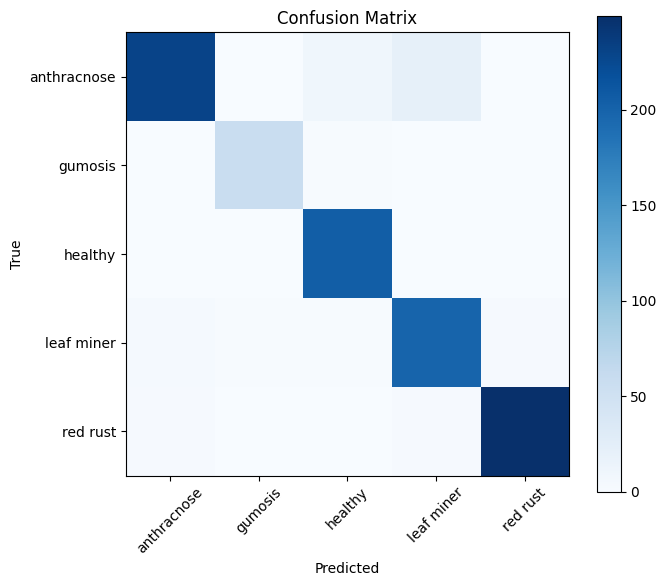

Crop: Cashew
Model: efficientnet_b0
Accuracy: 0.9573
              precision    recall  f1-score   support

 anthracnose       0.98      0.88      0.93       260
     gumosis       0.98      0.98      0.98        59
     healthy       0.95      1.00      0.97       205
  leaf miner       0.90      0.97      0.93       206
    red rust       0.99      0.98      0.99       253

    accuracy                           0.96       983
   macro avg       0.96      0.96      0.96       983
weighted avg       0.96      0.96      0.96       983



In [ ]:
plot_results(result_eff_cashew)


===== Maize | vgg16 =====
Class counts: [200 471 143 653 693 867 675]
Sample type: <class 'torch.Tensor'>
Sample shape: torch.Size([3, 224, 224])
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 87.8MB/s]


Epoch 1: Train Loss=1.6052, Train Acc=0.3541, Val Loss=1.5251, Val Acc=0.3178
Epoch 2: Train Loss=1.3021, Train Acc=0.4422, Val Loss=1.0286, Val Acc=0.5876
Epoch 3: Train Loss=1.0663, Train Acc=0.5194, Val Loss=1.0181, Val Acc=0.6015
Epoch 4: Train Loss=0.9092, Train Acc=0.5986, Val Loss=0.9099, Val Acc=0.5864
Epoch 5: Train Loss=0.8605, Train Acc=0.6351, Val Loss=0.7972, Val Acc=0.6431
Epoch 6: Train Loss=0.8110, Train Acc=0.6469, Val Loss=0.7998, Val Acc=0.6166
Epoch 7: Train Loss=0.7499, Train Acc=0.6640, Val Loss=0.7446, Val Acc=0.7112
Epoch 8: Train Loss=0.7963, Train Acc=0.6491, Val Loss=0.6903, Val Acc=0.7087
Epoch 9: Train Loss=0.6487, Train Acc=0.6948, Val Loss=0.9124, Val Acc=0.6772
Epoch 10: Train Loss=0.6932, Train Acc=0.7042, Val Loss=0.7314, Val Acc=0.7049
Epoch 11: Train Loss=0.5960, Train Acc=0.7226, Val Loss=0.7316, Val Acc=0.6520
Early stopping triggered.

Test Accuracy (Maize - vgg16): 0.6763


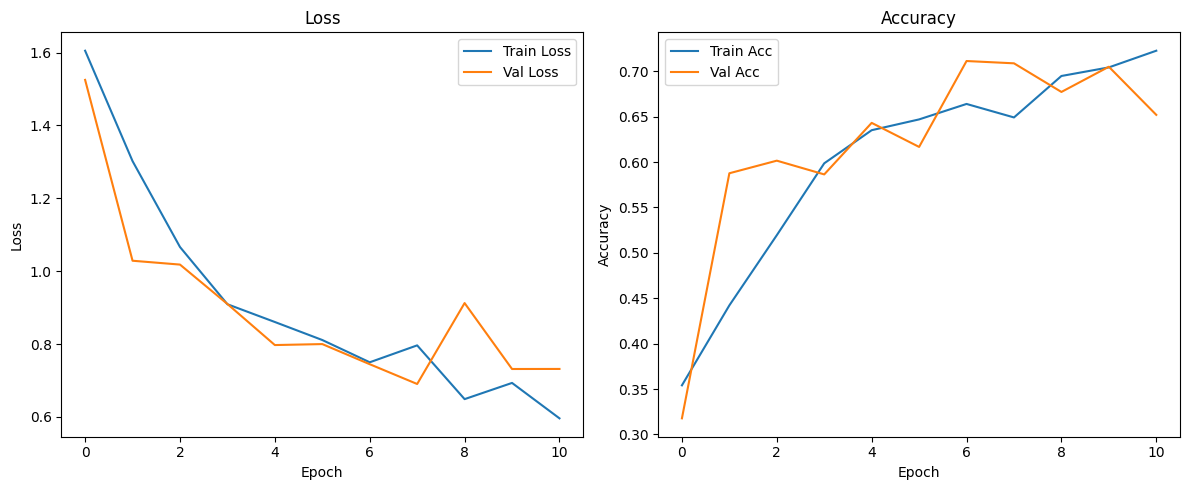

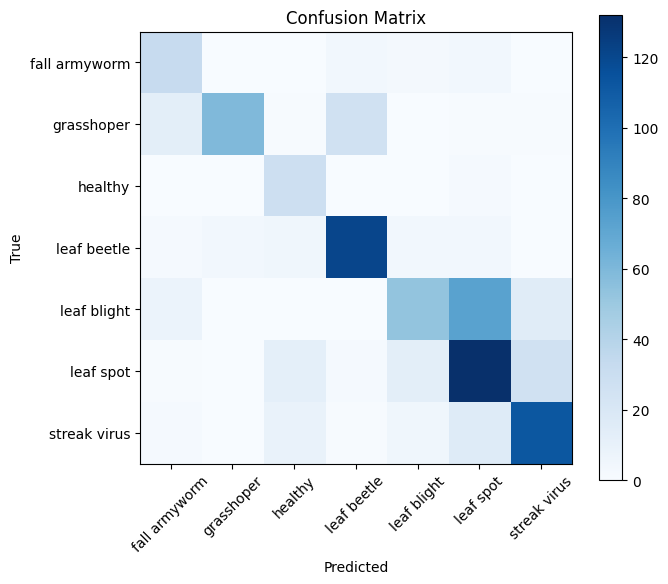

Crop: Maize
Model: vgg16
Accuracy: 0.6763
               precision    recall  f1-score   support

fall armyworm       0.55      0.74      0.63        43
   grasshoper       0.94      0.58      0.72       101
      healthy       0.51      0.93      0.66        30
  leaf beetle       0.79      0.86      0.82       140
  leaf blight       0.68      0.36      0.47       149
    leaf spot       0.57      0.71      0.63       186
 streak virus       0.73      0.77      0.75       145

     accuracy                           0.68       794
    macro avg       0.68      0.71      0.67       794
 weighted avg       0.70      0.68      0.67       794



In [ ]:
result_vgg_maize  = run_crop_experiment("Maize", "vgg16")
plot_results(result_vgg_maize)


===== Cashew | vgg16 =====
Class counts: [1210  274  958  965 1177]
Sample type: <class 'torch.Tensor'>
Sample shape: torch.Size([3, 224, 224])
Epoch 1: Train Loss=1.5381, Train Acc=0.2818, Val Loss=1.0851, Val Acc=0.5173
Epoch 2: Train Loss=1.0019, Train Acc=0.5537, Val Loss=0.8563, Val Acc=0.5560
Epoch 3: Train Loss=0.8967, Train Acc=0.5923, Val Loss=0.7502, Val Acc=0.6253
Epoch 4: Train Loss=0.7050, Train Acc=0.6627, Val Loss=0.7314, Val Acc=0.7271
Epoch 5: Train Loss=0.6719, Train Acc=0.6887, Val Loss=0.9513, Val Acc=0.5387
Epoch 6: Train Loss=0.6279, Train Acc=0.7173, Val Loss=0.5611, Val Acc=0.7464
Epoch 7: Train Loss=0.6082, Train Acc=0.7485, Val Loss=0.7084, Val Acc=0.6507
Epoch 8: Train Loss=0.5803, Train Acc=0.7304, Val Loss=0.5167, Val Acc=0.7729
Epoch 9: Train Loss=0.4793, Train Acc=0.7851, Val Loss=0.4033, Val Acc=0.8198
Epoch 10: Train Loss=0.4471, Train Acc=0.8065, Val Loss=0.3802, Val Acc=0.8523
Epoch 11: Train Loss=0.4199, Train Acc=0.8233, Val Loss=0.4895, Val Acc=0.

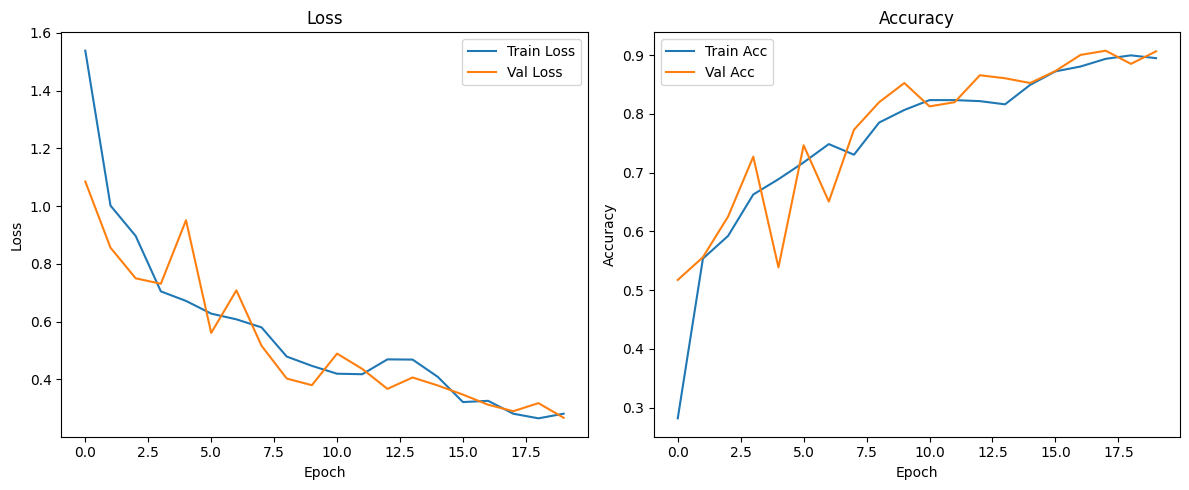

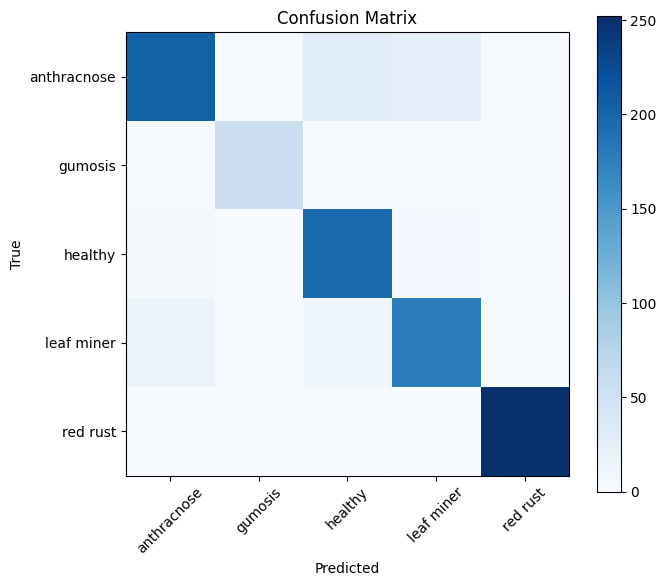

Crop: Cashew
Model: vgg16
Accuracy: 0.9003
              precision    recall  f1-score   support

 anthracnose       0.91      0.78      0.84       260
     gumosis       0.93      0.95      0.94        59
     healthy       0.83      0.95      0.89       205
  leaf miner       0.86      0.86      0.86       206
    red rust       0.98      1.00      0.99       253

    accuracy                           0.90       983
   macro avg       0.90      0.91      0.90       983
weighted avg       0.90      0.90      0.90       983



In [ ]:
result_vgg_cashew = run_crop_experiment("Cashew", "vgg16")
plot_results(result_vgg_cashew)